# Random forest Regression


In [63]:
#import libary
import pandas as pd
import streamlit as st
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
import os

file_path = "car_price_prediction.csv"

if os.path.exists(file_path):

    data = pd.read_csv(file_path)

else:

    st.error("Dataset file not found.")
    st.stop()

2026-05-18 21:55:00.781 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-18 21:55:00.954 
  command:

    streamlit run C:\Users\chand\AppData\Roaming\Python\Python313\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-05-18 21:55:00.954 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-18 21:55:00.955 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-18 21:55:00.955 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [65]:
df.head()

,Brand,Year,Engine Size,Fuel Type,Transmission,Price,Model,Mileage_36,Mileage_45,Mileage_56,...,Mileage_299225,Mileage_299260,Mileage_299334,Mileage_299355,Mileage_299461,Mileage_299738,Mileage_299854,Mileage_299967,Condition_New,Condition_Used
0,5,2016,2.3,3,1,26613.92,19,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,1,2018,4.4,1,1,14679.61,1,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,0,2013,4.5,1,1,44402.61,3,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,5,2011,4.1,0,0,86374.33,20,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,2,2009,2.6,0,1,73577.10,21,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [66]:
# Display column names
df.columns

Index(['Brand', 'Year', 'Engine Size', 'Fuel Type', 'Transmission', 'Price',
       'Model', 'Mileage_36', 'Mileage_45', 'Mileage_56',
       ...
       'Mileage_299225', 'Mileage_299260', 'Mileage_299334', 'Mileage_299355',
       'Mileage_299461', 'Mileage_299738', 'Mileage_299854', 'Mileage_299967',
       'Condition_New', 'Condition_Used'],
      dtype='object', length=2498)

In [67]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Columns: 2498 entries, Brand to Condition_Used
dtypes: bool(2491), float64(2), int64(5)
memory usage: 6.1 MB


In [68]:
# Statistical summary
df.describe()

,Brand,Year,Engine Size,Fuel Type,Transmission,Price,Model
count,2500.000000,2500.0000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,3.001600,2011.6268,3.465240,1.482400,0.523200,52638.022532,13.255600
std,2.020503,6.9917,1.432053,1.130576,0.499561,27295.833455,8.106229
min,0.000000,2000.0000,1.000000,0.000000,0.000000,5011.270000,0.000000
25%,1.000000,2005.0000,2.200000,0.000000,0.000000,28908.485000,6.000000
50%,3.000000,2012.0000,3.400000,1.000000,1.000000,53485.240000,13.000000
75%,5.000000,2018.0000,4.700000,3.000000,1.000000,75838.532500,20.000000
max,6.000000,2023.0000,6.000000,3.000000,1.000000,99982.590000,27.000000


In [69]:
# Target column
print("Price is the target column we want to predict.")

Price is the target column we want to predict.


In [70]:
# Check missing values
df.isnull().sum()

Brand             0
Year              0
Engine Size       0
Fuel Type         0
Transmission      0
                 ..
Mileage_299738    0
Mileage_299854    0
Mileage_299967    0
Condition_New     0
Condition_Used    0
Length: 2498, dtype: int64

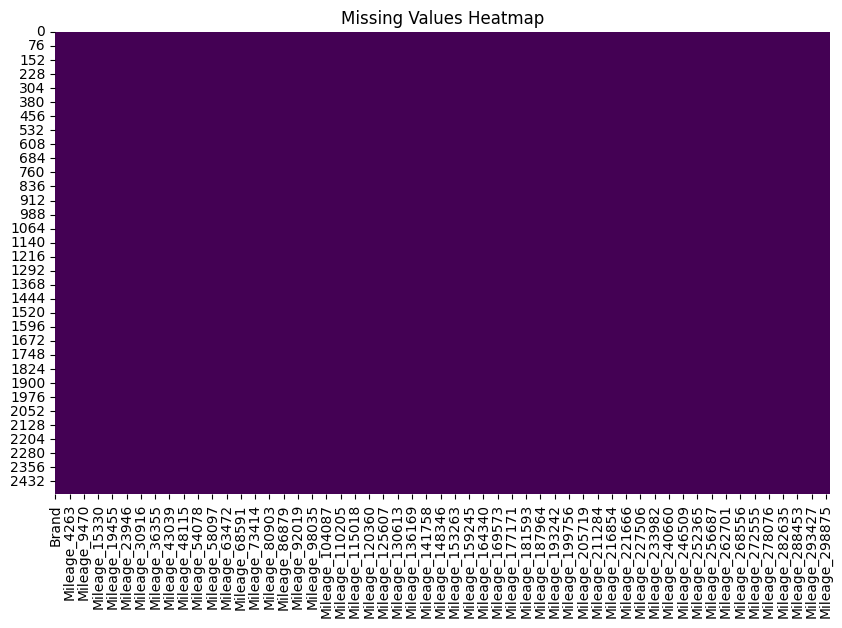

In [71]:
#heatmap to visualize missing values
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

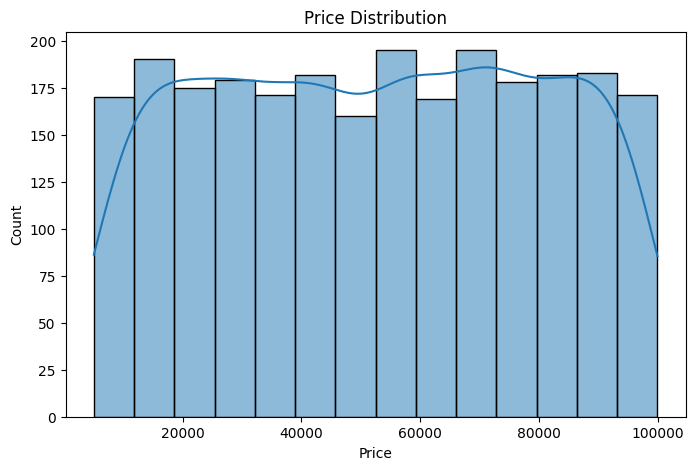

In [72]:
# Price distribution
plt.figure(figsize=(8,5))
sns.histplot(df["Price"], kde=True)
plt.title("Price Distribution")
plt.show()

In [ ]:
# Correlation heatmap
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


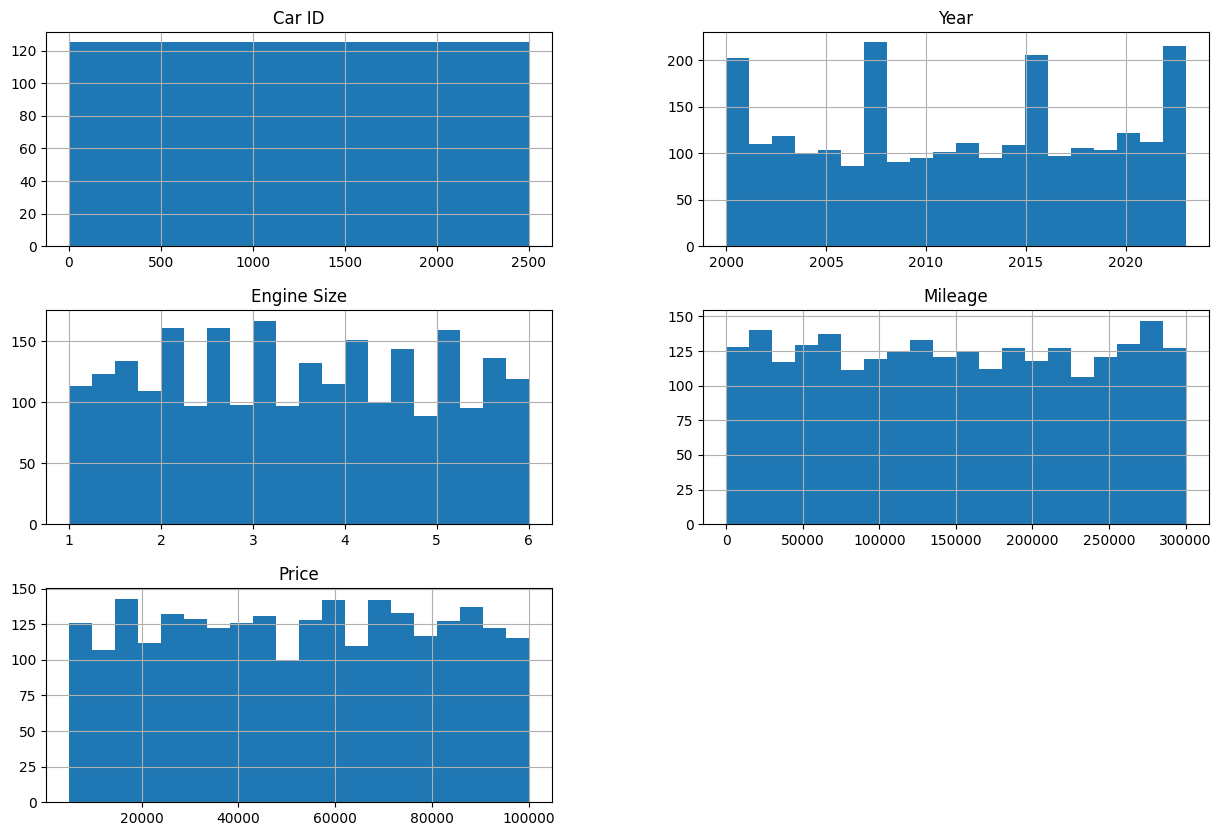

In [ ]:
# Histograms
df.hist(figsize=(15,10), bins=20)
plt.show()


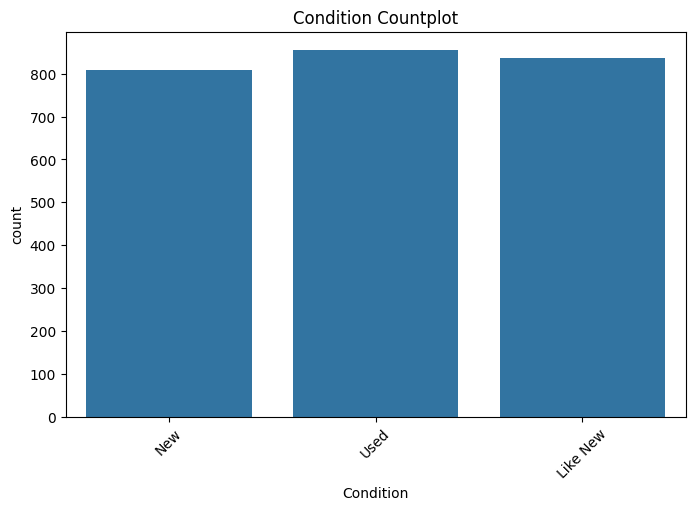

In [ ]:
# Countplot for Condition
plt.figure(figsize=(8,5))
sns.countplot(x=df["Condition"])
plt.title("Condition Countplot")
plt.xticks(rotation=45)
plt.show()


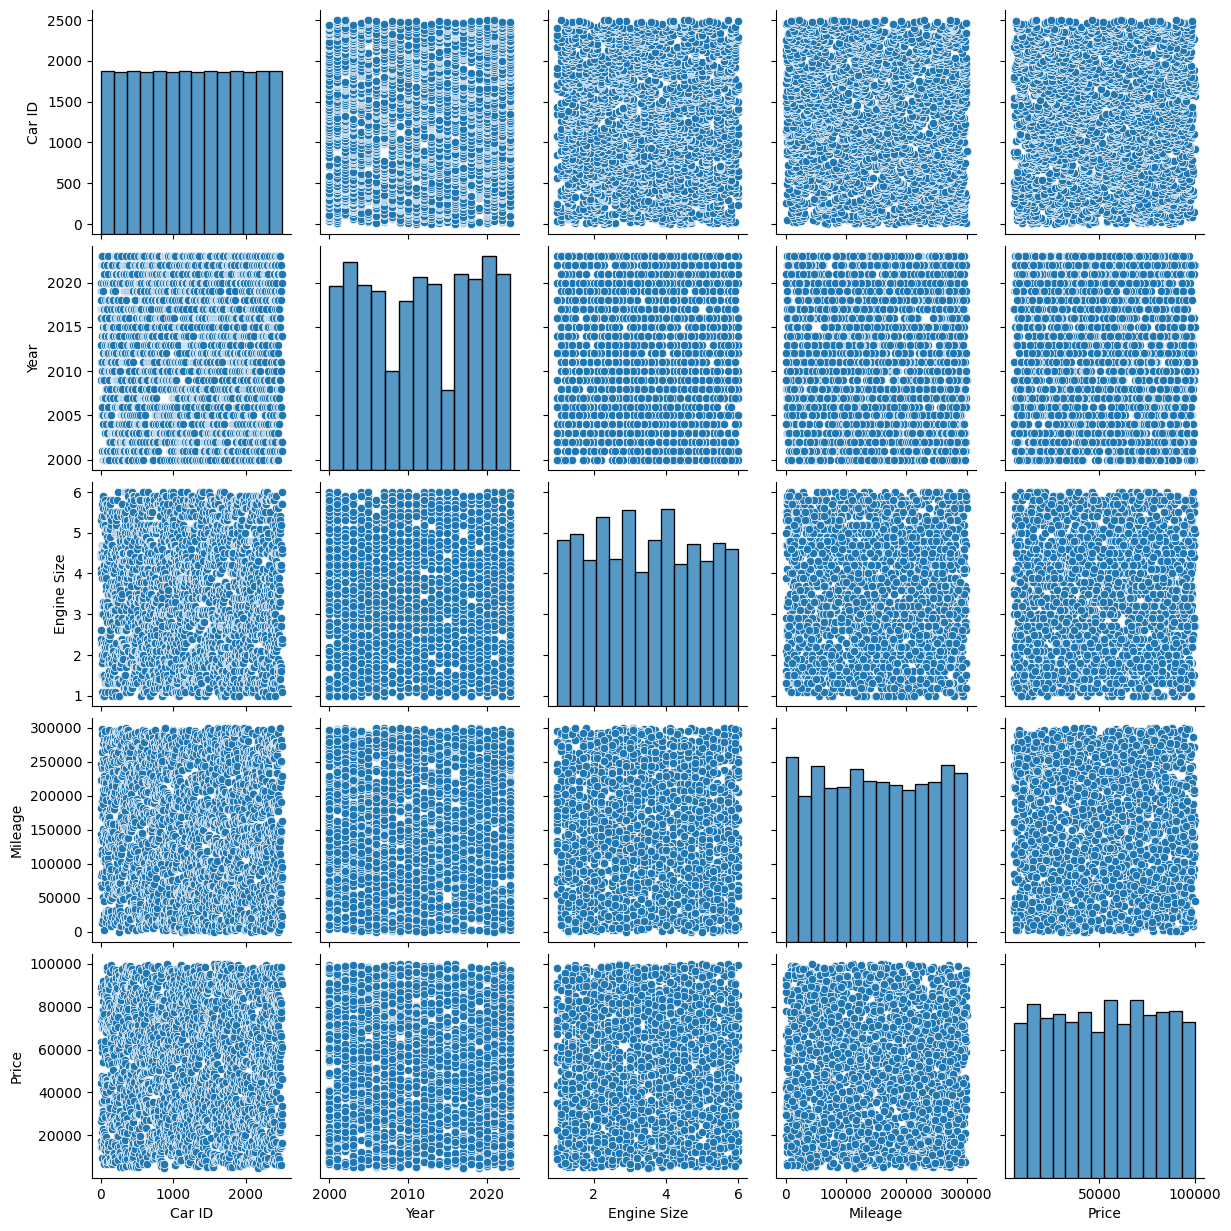

In [ ]:
#pairplot
sns.pairplot(df)
plt.show()


In [ ]:
# Numeric columns
num_cols = df.select_dtypes(include=np.number).columns
print(num_cols)

Index(['Car ID', 'Year', 'Engine Size', 'Mileage', 'Price'], dtype='object')


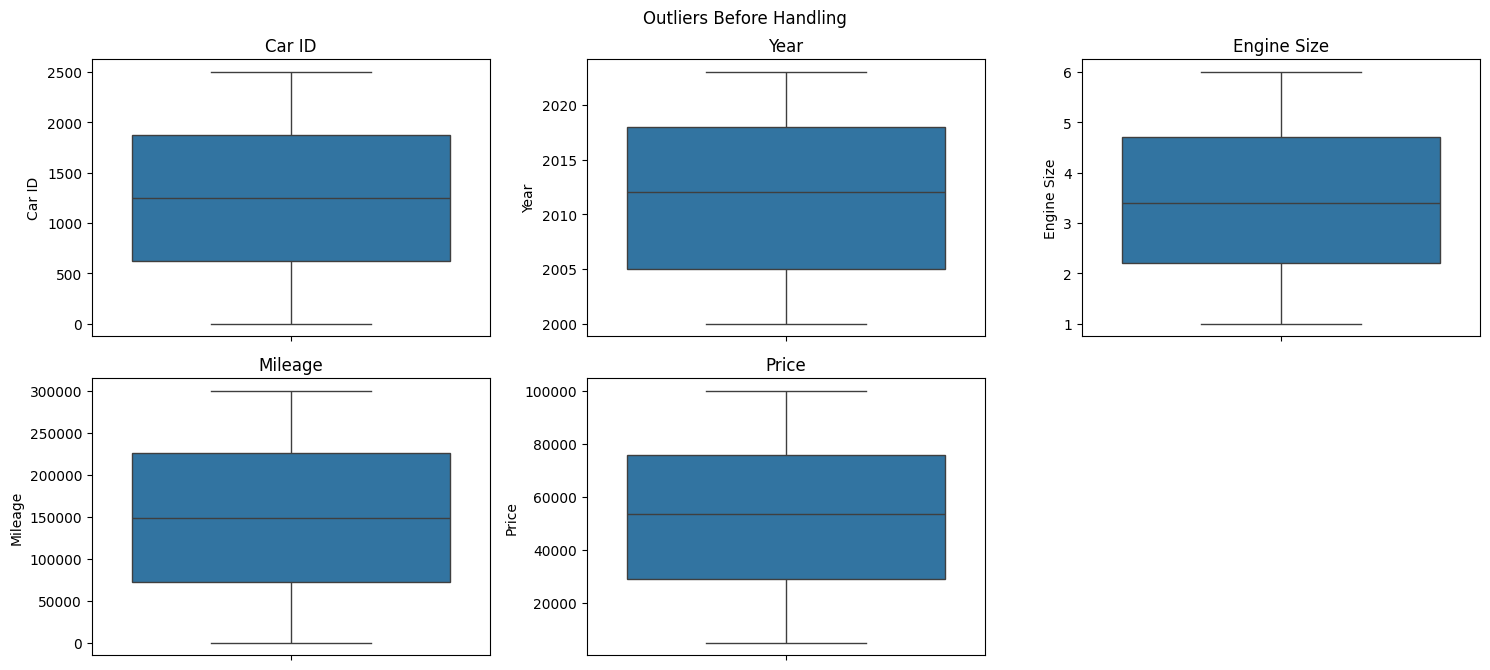

In [ ]:
# Boxplots before handling outliers
plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(3,3,i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.suptitle("Outliers Before Handling")
plt.tight_layout()
plt.show()


In [ ]:
# Shape before removing outliers
print("Shape Before:", df.shape)

Shape Before: (2500, 10)


In [ ]:
# Remove outliers except Price
outlier_cols = [col for col in num_cols if col != "Price"]

for col in outlier_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df = df[(df[col] >= lower) & (df[col] <= upper)]

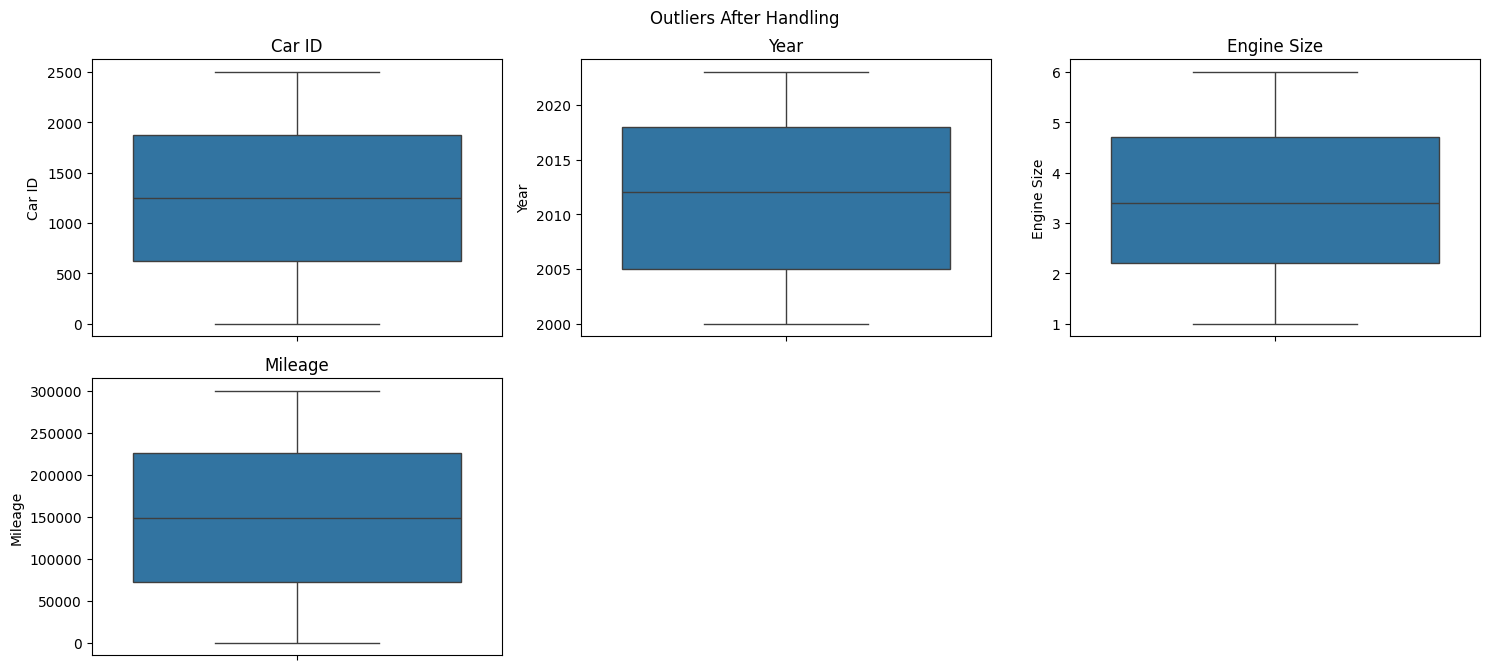

In [ ]:
# Boxplots after handling outliers
plt.figure(figsize=(15,10))

for i, col in enumerate(outlier_cols, 1):
    plt.subplot(3,3,i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.suptitle("Outliers After Handling")
plt.tight_layout()
plt.show()


In [ ]:
df.columns

Index(['Car ID', 'Brand', 'Year', 'Engine Size', 'Fuel Type', 'Transmission',
       'Mileage', 'Condition', 'Price', 'Model'],
      dtype='object')

In [ ]:
#remove car id column
df = df.drop("Car ID", axis=1)


In [ ]:
df.columns.tolist()

['Brand',
 'Year',
 'Engine Size',
 'Fuel Type',
 'Transmission',
 'Mileage',
 'Condition',
 'Price',
 'Model']

In [ ]:
# One hot encoding
df = pd.get_dummies(df, columns=["Mileage","Condition"], drop_first=True)

In [ ]:
# Display encoded dataset
df.head()

,Brand,Year,Engine Size,Fuel Type,Transmission,Price,Model,Mileage_36,Mileage_45,Mileage_56,...,Mileage_299225,Mileage_299260,Mileage_299334,Mileage_299355,Mileage_299461,Mileage_299738,Mileage_299854,Mileage_299967,Condition_New,Condition_Used
0,Tesla,2016,2.3,Petrol,Manual,26613.92,Model X,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,BMW,2018,4.4,Electric,Manual,14679.61,5 Series,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,Audi,2013,4.5,Electric,Manual,44402.61,A4,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,Tesla,2011,4.1,Diesel,Automatic,86374.33,Model Y,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,Ford,2009,2.6,Diesel,Manual,73577.10,Mustang,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
# Features
X = df.drop("Price", axis=1)
# Target
y = df["Price"]
X
y

0       26613.92
1       14679.61
2       44402.61
3       86374.33
4       73577.10
          ...   
2495    61384.10
2496    24710.35
2497    29902.45
2498    46085.67
2499    16594.14
Name: Price, Length: 2500, dtype: float64

In [ ]:
# Check data types again
X.dtypes

Brand              object
Year                int64
Engine Size       float64
Fuel Type          object
Transmission       object
                   ...   
Mileage_299738       bool
Mileage_299854       bool
Mileage_299967       bool
Condition_New        bool
Condition_Used       bool
Length: 2497, dtype: object

In [ ]:
# Shape after removing outliers
print("Shape After:", X.shape)


Shape After: (2500, 2497)


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Create encoder
le = LabelEncoder()

# Encode all object/string columns
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [ ]:
# Features and target
X = df.drop("Price", axis=1)
y = df["Price"]

# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [ ]:
# Import model
from sklearn.ensemble import RandomForestRegressor
# Create model
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
model

RandomForestRegressor(random_state=42)

In [ ]:
# Train model
model.fit(X_train, y_train)
# Predict values
y_pred = model.predict(X_test)
# Training message
print("Model trained successfully")


Model trained successfully


In [ ]:
# Comparison dataframe
comparison = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

In [ ]:
# Display first 10 rows
comparison.head(10)

,Actual Price,Predicted Price
1447,17494.90,66117.6630
1114,75919.94,44112.6848
1064,87474.10,47908.4431
2287,13522.58,50937.1221
1537,77070.57,46598.8533
668,40085.49,49425.3548
1583,47196.40,58732.2644
2404,58558.94,53888.5851
497,23029.74,63381.4013
2480,32351.06,58678.6618


In [ ]:
# Import evaluation metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [ ]:
# MAE
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)
# MSE
mse = mean_squared_error(y_test, y_pred)    
print("MSE:", mse)
#rmse
rmse = np.sqrt(mse)
print("RMSE:", rmse)
# R² Score
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

MAE: 24599.0255432
MSE: 823650889.9523659
RMSE: 28699.31863219693
R² Score: -0.08725135888343938


In [ ]:
# Feature importance dataframe
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

In [ ]:
importance

,Feature,Importance
0,Brand,0.033795
1,Year,0.087250
2,Engine Size,0.118741
3,Fuel Type,0.032917
4,Transmission,0.017225
...,...,...
2492,Mileage_299738,0.000000
2493,Mileage_299854,0.000000
2494,Mileage_299967,0.000235
2495,Condition_New,0.012691


In [ ]:
# Sort importance
importance = importance.sort_values(by="Importance", ascending=False)

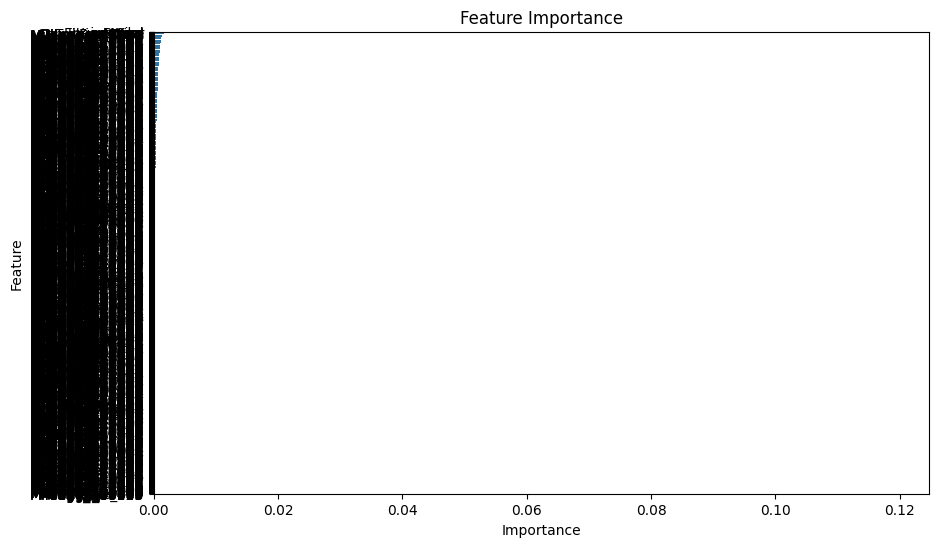

Features with higher importance affect house price more.


In [ ]:
# Feature importance plot
plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=importance)
plt.title("Feature Importance")
plt.show()
# Important feature explanation
print("Features with higher importance affect house price more.")

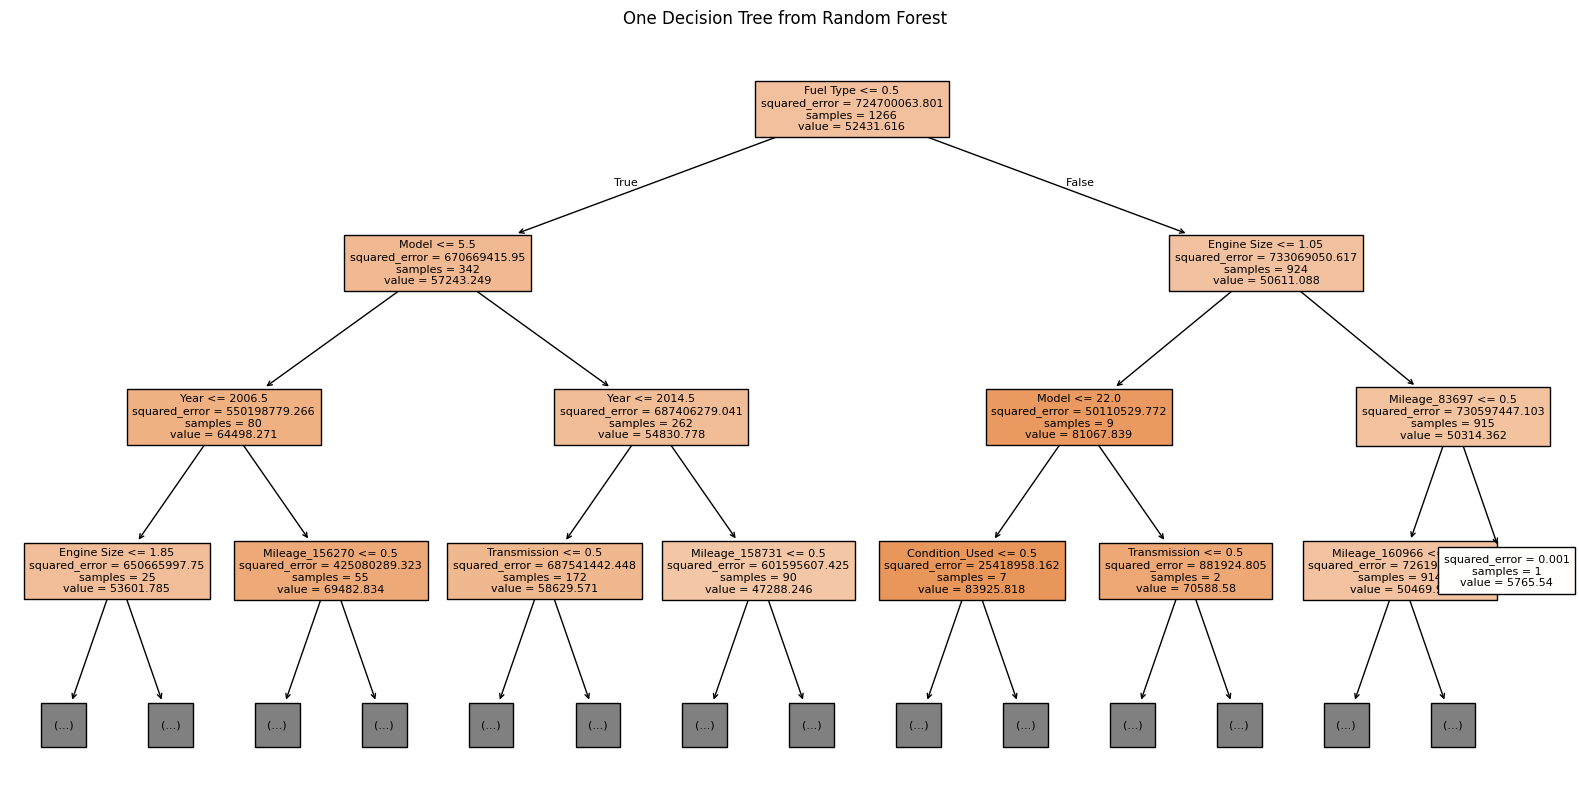

In [ ]:
# Import tree visualization
from sklearn.tree import plot_tree

# Visualize one tree from Random Forest
plt.figure(figsize=(20,10))

plot_tree(
    model.estimators_[1],
    filled=True,
    feature_names=X.columns,
    max_depth=3,
    fontsize=8
)

plt.title("One Decision Tree from Random Forest")

plt.show()


In [ ]:
# Tree explanation
print("This is only one tree inside the forest.")
print("Final prediction comes from multiple trees working together.")

This is only one tree inside the forest.
Final prediction comes from multiple trees working together.
